# 02_分类算法-ID3算法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 信息熵正确处理 0·log(0)，训练与预测复用同一编码。scikit-learn 的 entropy 决策树是二叉 CART；末尾另附离散多分支 ID3 实现，明确两者区别。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


在学习决策树的时候，大家一定遇到了其中的ID3算法。

ID3算法（Iterative Dichotomiser 3）本身是一种用于分类的决策树算法，由Ross Quinlan在1986年提出。

它基于信息论中的**信息增益**概念，递归地选择具有最高信息增益的属性作为节点，将数据划分为多个子集，直到满足停止条件（如所有样本属于同一类别或没有剩余属性）为止。

### ID3核心步骤

1. 计算每个特征的信息增益。
2. 选择信息增益最高的特征作为当前节点的分裂标准。
3. 对分裂后的子数据集递归重复步骤1和2，构建决策树。
4. 停止条件为：所有数据属于同一类别，或数据集不可分，或特征用尽。

简单举例来说，假设你是个侦探，想通过观察一些线索来推断一个案件的可能结果，比如「是事故还是犯罪」。

你有以下线索：

- 天气
- 地点
- 目击者数量
- 时间段

ID3算法就像一个逻辑筛选器：

1. **挑线索**：先挑出最关键的线索，比如「目击者数量」可能是影响结果的最重要因素，因为它能最清晰地区分案件类型。
2. **用线索分类**：根据「目击者数量」分类，比如：

   - 如果目击者是0，很可能是事故。
   - 如果目击者很多，可能是犯罪。
3. **继续挑下一个线索**：在目击者数量的基础上，再挑选其他次重要的线索，比如「时间段」。
4. **层层筛选**：每次都用最能帮你区分的线索，直到你有明确答案。

最终，你会构建出一个逻辑决策的树形结构，像「如果目击者=0，结果=事故；如果目击者很多且时间是夜晚，结果=犯罪」。

简单说，ID3算法就是一套「不断挑最重要线索、用线索分类」的方法，帮助你从复杂数据中得出最清晰的判断。

## 理论基础

ID3算法的核心数学基础是**信息论**中的**信息熵（Entropy）和信息增益（Information Gain）**。

#### 信息熵（Entropy）

信息熵衡量的是系统的混乱程度或不确定性。假设数据集 $S$包含 $n$个样本，分类结果有 $c$个类别 $\{C_1, C_2, \dots, C_c\}$，其中第 $i$类样本的概率为 $p_i$，则信息熵的定义为：


$$
H(S) = -\sum_{i=1}^c p_i \log_2 p_i
$$


$H(S)$：数据集 $S$的信息熵。

$p_i$：属于第 $i$类的样本比例，计算方式为 $p_i = \frac{|S_i|}{|S|}$，其中 $|S_i|$是第 $i$类的样本数量，$|S|$是样本总数。

- 信息熵越高，数据的不确定性越大；信息熵为0时，数据完全确定（即所有样本属于同一类别）。

#### 条件熵（Conditional Entropy）

条件熵表示在给定某个特征 $A$的条件下，数据集 $S$的不确定性。假设特征 $A$有 $v$个可能的取值 $\{a_1, a_2, \dots, a_v\}$，将数据集 $S$根据特征 $A$的取值划分为 $v$个子集 $S_1, S_2, \dots, S_v$，则条件熵定义为：


$$
H(S|A) = \sum_{i=1}^v \frac{|S_i|}{|S|} H(S_i)
$$


$|S_i|$：子集 $S_i$的样本数量。

$H(S_i)$：子集 $S_i$的信息熵。

条件熵衡量的是特征 $A$对数据集 $S$的分类效果。条件熵越小，说明 $A$的分类效果越好。

#### 信息增益（Information Gain）

信息增益衡量的是由于特征 $A$的引入，数据集 $S$的不确定性减少的程度。信息增益定义为：


$$
G(S, A) = H(S) - H(S|A)
$$


$G(S, A)$：特征 $A$的信息增益。

$H(S)$：数据集 $S$的信息熵。

$H(S|A)$：在给定特征 $A$的条件下，数据集 $S$的条件熵。

信息增益越大，说明特征 $A$的分类效果越好。

#### 特征选择

在构建决策树时，ID3算法选择信息增益最大的特征作为当前节点的分裂标准。

### **ID3算法的流程**

**1. 输入**：数据集 $S$、特征集合 $A$、类别标签集合 $C$。

**2. 输出**：决策树。

**3. 步骤**：

**Step 1: 计算根节点的信息熵**

- 根据类别标签计算数据集 $S$的信息熵 $H(S)$。

**Step 2: 计算每个特征的信息增益**

- 对于每个特征 $A$：

  1. 根据 $A$的可能取值，将数据集 $S$划分为多个子集 $S_1, S_2, \dots, S_v$。
  2. 计算特征 $A$的条件熵 $H(S|A)$。
  3. 计算特征 $A$的信息增益 $G(S, A) = H(S) - H(S|A)$。

**Step 3: 选择信息增益最大的特征**

- 找到具有最大信息增益的特征 $A_{\text{best}}$。
- 如果所有特征的信息增益都很小（低于设定阈值）或样本无法继续分裂，则停止分裂。

**Step 4: 构建决策树节点**

- 使用 $A_{\text{best}}$创建一个决策树节点。
- 根据 $A_{\text{best}}$的取值划分数据集，生成对应的分支。

**Step 5: 对子集递归构建决策树**

- 对于每个子集 $S_i$：

  1. 如果子集 $S_i$中的样本全属于同一类别，则将当前分支标记为叶子节点，类别为该类别。
  2. 如果子集 $S_i$中没有剩余特征，则将当前分支标记为叶子节点，类别为该子集样本中占比最大的类别。
  3. 否则，对子集 $S_i$的剩余特征集合递归执行上述步骤。

**Step 6: 终止条件**

- 所有样本属于同一类别。
- 没有剩余特征可以分裂。
- 样本无法继续分裂（即样本数量小于设定阈值）。

1. **输出决策树**：返回构建好的决策树。

ID3算法的核心在于使用**信息增益**选择最优特征，通过递归地分裂数据集构建决策树。它优点在于简单直观，适合处理离散特征的数据集，但由于偏向选择取值较多的特征，可能导致过拟合问题。

## 应用场景

### ID3算法适用问题类型

1. **分类问题**：ID3算法用于解决具有**离散特征**的数据分类任务。
2. **目标变量是离散的**：目标变量必须是类别（如“是/否”或多类别）。
3. **适合较小规模数据集**：ID3适合中小规模数据集，大规模数据可能导致性能下降。

**优点**：

1. **易于理解和实现**：决策树结构直观，算法简单。
2. **高效处理离散数据**：天然适合离散特征。
3. **无需数据预处理**：不需要对特征进行归一化或缩放。
4. **结果可解释性强**：构造出的树形结构便于人类理解分类规则。

**缺点**：

1. **易于过拟合**：ID3倾向于选择取值较多的特征（偏向分裂次数多的特征），可能导致过拟合。
2. **处理连续特征能力差**：需要对连续特征进行离散化。
3. **对噪声敏感**：噪声数据可能显著影响结果。
4. **偏向信息增益高的特征**：可能导致重要特征被忽略。
5. **不适合动态变化的特征集**：算法需要从头训练决策树。

### 运用时的前提条件

1. **特征是离散的**：ID3不直接处理连续特征，需预处理为离散数据。
2. **数据无严重噪声**：数据质量较高的情况下效果较好。
3. **特征独立性假设**：算法假设特征之间相互独立。
4. **类别明确**：目标变量的类别已知且分布较平衡。

## 完整案例

一个完整的 **ID3 算法案例**，包括 Python 实现、数据集、生成决策树以及绘制数据分析图表。

整个案例展示了如何用 ID3 算法分类数据，图表包括特征选择的信息增益分析和决策树的可视化。

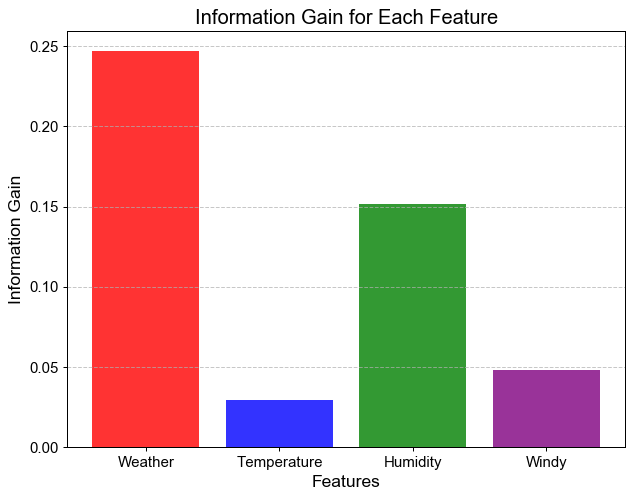

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.stats import entropy

# 1. 生成虚拟数据集
data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast', 'Sunny', 
                'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 
                    'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 
                 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': ['False', 'True', 'False', 'False', 'False', 'True', 'True', 'False', 
              'False', 'False', 'True', 'True', 'False', 'True'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 
                   'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)

# 2. 数据预处理
# 将分类变量转换为数值
encoders = {}
for column in df.columns:
    encoders[column] = LabelEncoder()
    df[column] = encoders[column].fit_transform(df[column])

# 特征和目标变量
X = df[['Weather', 'Temperature', 'Humidity', 'Windy']]
y = df['PlayTennis']

# 3. 构建 ID3 决策树
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X, y)

# 4. 输出信息增益分析
features = ['Weather', 'Temperature', 'Humidity', 'Windy']
info_gain = []
H_S = entropy(np.bincount(y), base=2)  # 数据集熵
for i, feature in enumerate(features):
    unique_values = np.unique(X.iloc[:, i])
    H_S_A = 0
    for value in unique_values:
        subset = y[X.iloc[:, i] == value]
        p = len(subset) / len(y)
        H_S_A += p * entropy(np.bincount(subset), base=2)
    info_gain.append(H_S - H_S_A)

# 可视化信息增益
plt.figure(figsize=(8, 6))
plt.bar(features, info_gain, color=['red', 'blue', 'green', 'purple'], alpha=0.8)
plt.title("Information Gain for Each Feature", fontsize=16)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Information Gain", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

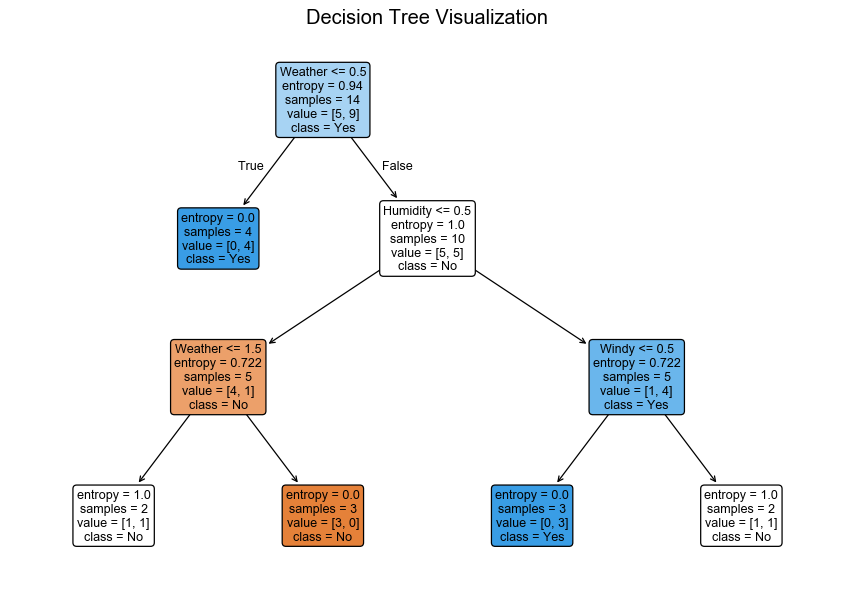

Predictions for test data: [1 0 1]
Optimized Predictions: [1 0 1]
Model Accuracy on Training Data: 0.8571428571428571
ID3 multiway tree: {'feature': 'Weather', 'default': 1, 'branches': {2: {'feature': 'Humidity', 'default': 0, 'branches': {0: 0, 1: 1}}, 0: 1, 1: {'feature': 'Windy', 'default': 1, 'branches': {0: 1, 1: 0}}}}
ID3 predictions: ['Yes' 'No' 'Yes']


In [3]:
# 5. 决策树可视化
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=features, class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization", fontsize=16)
plt.show()

# 6. 测试与优化
# 模拟新数据
test_data = pd.DataFrame({
    'Weather': ['Sunny', 'Rainy', 'Overcast'],
    'Temperature': ['Hot', 'Mild', 'Cool'],
    'Humidity': ['Normal', 'High', 'High'],
    'Windy': ['False', 'True', 'False']
})

# 数据转换
for column in test_data.columns:
    test_data[column] = encoders[column].transform(test_data[column])

# 预测
predictions = model.predict(test_data)
print("Predictions for test data:", predictions)

# 优化策略（可选）：调整树的深度，选择特征重要性
optimized_model = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)
optimized_model.fit(X, y)
optimized_predictions = optimized_model.predict(test_data)
print("Optimized Predictions:", optimized_predictions)

# 输出准确率（仅供模拟）
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print("Model Accuracy on Training Data:", accuracy)
# 真正的离散多分支 ID3：按信息增益选择特征，每个类别取值对应一个分支。
def fit_id3(X_data, labels):
    labels = np.asarray(labels)
    classes, counts = np.unique(labels, return_counts=True)
    majority = classes[np.argmax(counts)]
    if len(classes) == 1 or X_data.shape[1] == 0:
        return int(majority)
    base = entropy(counts, base=2)
    gains = {}
    for feature in X_data.columns:
        conditional = 0.0
        for value in X_data[feature].unique():
            mask = (X_data[feature] == value).to_numpy()
            conditional += mask.mean() * entropy(np.unique(labels[mask], return_counts=True)[1], base=2)
        gains[feature] = base - conditional
    best = max(gains, key=gains.get)
    if gains[best] <= 1e-12:
        return int(majority)
    branches = {}
    for value in X_data[best].unique():
        mask = (X_data[best] == value).to_numpy()
        branches[int(value)] = fit_id3(X_data.loc[mask].drop(columns=best), labels[mask])
    return {'feature': best, 'default': int(majority), 'branches': branches}

def predict_id3(tree, row):
    if not isinstance(tree, dict):
        return tree
    child = tree['branches'].get(int(row[tree['feature']]), tree['default'])
    return predict_id3(child, row)

id3_tree = fit_id3(X, y)
id3_predictions = np.array([predict_id3(id3_tree, row) for _, row in test_data.iterrows()])
print('ID3 multiway tree:', id3_tree)
print('ID3 predictions:', encoders['PlayTennis'].inverse_transform(id3_predictions))
assert np.isfinite(info_gain).all()

**信息增益柱状图**：柱状图显示了每个特征的**信息增益**，帮助理解哪些特征对分类贡献最大。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

**决策树可视化**：决策树直观展示了分类规则，从根节点到叶子节点的路径即分类逻辑。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

**优化策略**：通过限制树的最大深度，减少过拟合风险。预测新数据并评估模型的表现。

### 改进优化方法

1. **剪枝策略**：使用后剪枝技术，移除冗余节点。
2. **特征选择**：结合特征重要性，去除信息增益低的特征。
3. **交叉验证**：使用交叉验证评估模型性能，避免单一数据集的偏差。
4. **处理连续特征**：对连续特征进行分段处理（如分箱或聚类）。